In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')


In [6]:
df =pd.read_csv(r'D:\iec\ass1\python\portfolio2\66634-ev-data\Electric_Vehicle_Population_Data.csv')
print(f"columns :list{df.columns}")
print(df.isnull().sum())



columns :listIndex(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='str')
VIN (1-10)                                             0
County                                                 5
City                                                   5
State                                                  0
Postal Code                                            5
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base M

In [7]:
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.family': 'DejaVu Sans',
})
BLUE    = '#378ADD'
GREEN   = '#1D9E75'
CORAL   = '#D85A30'
PINK    = '#D4537E'
PURPLE  = '#7F77DD'
AMBER   = '#BA7517'
PALETTE = [BLUE, GREEN, CORAL, PINK, PURPLE, AMBER, '#0F6E56', '#639922', '#D4537E', '#888780']
C_BEV    = '#00D4FF'
C_PHEV   = '#FF6B35'
C_ACCENT = '#7DF9FF'
C_DARK   = '#0A0E1A'
C_CARD   = '#111827'
C_GRID   = 'rgba(255,255,255,0.06)'
C_TEXT   = '#E2E8F0'
C_SUB    = '#94A3B8'
 
FONT_TITLE = 'Rajdhani'
FONT_BODY  = 'IBM Plex Mono'
 
google_fonts = (
    "https://fonts.googleapis.com/css2?"
    "family=Rajdhani:wght@400;600;700&"
    "family=IBM+Plex+Mono:wght@400;500&display=swap")

In [ ]:
total = df['Electric Vehicle Type'].notna().sum()
Bev_count = (df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)').sum()
Phev_count  = (df['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)').sum()
Bevp = Bev_count/total*100
Phevp = Phev_count/total*100
top_make = df['Make'].value_counts().idxmax()
top_county = df['County'].value_counts().idxmax()
top_City = df['City'].value_counts().idxmax()
top_model = df['Model'].value_counts().idxmin()

print("Bev Total EVs:", Bev_count)
print("Phev Total EVs:", Phev_count)
print("Bev%: ", Bevp)
print("Phev%: ", Phevp)
print("Top Maker: ", top_make)
print("Top Model: ",top_model)
print("Top City: ", top_City)
print("Top County: ", top_county)



Bev Total EVs: 139210
Phev Total EVs: 38656
Bev%:  78.26678510789021
Phev%:  21.73321489210979
Top Maker:  TESLA
Top Model:  918
Top City:  Seattle
Top County:  King


In [9]:
ev_counts = df['Electric Vehicle Type'].value_counts()
ev_counts.index=['Battery Electric Vehicle (BEV)','Plug-in Hybrid Electric Vehicle (PHEV)']

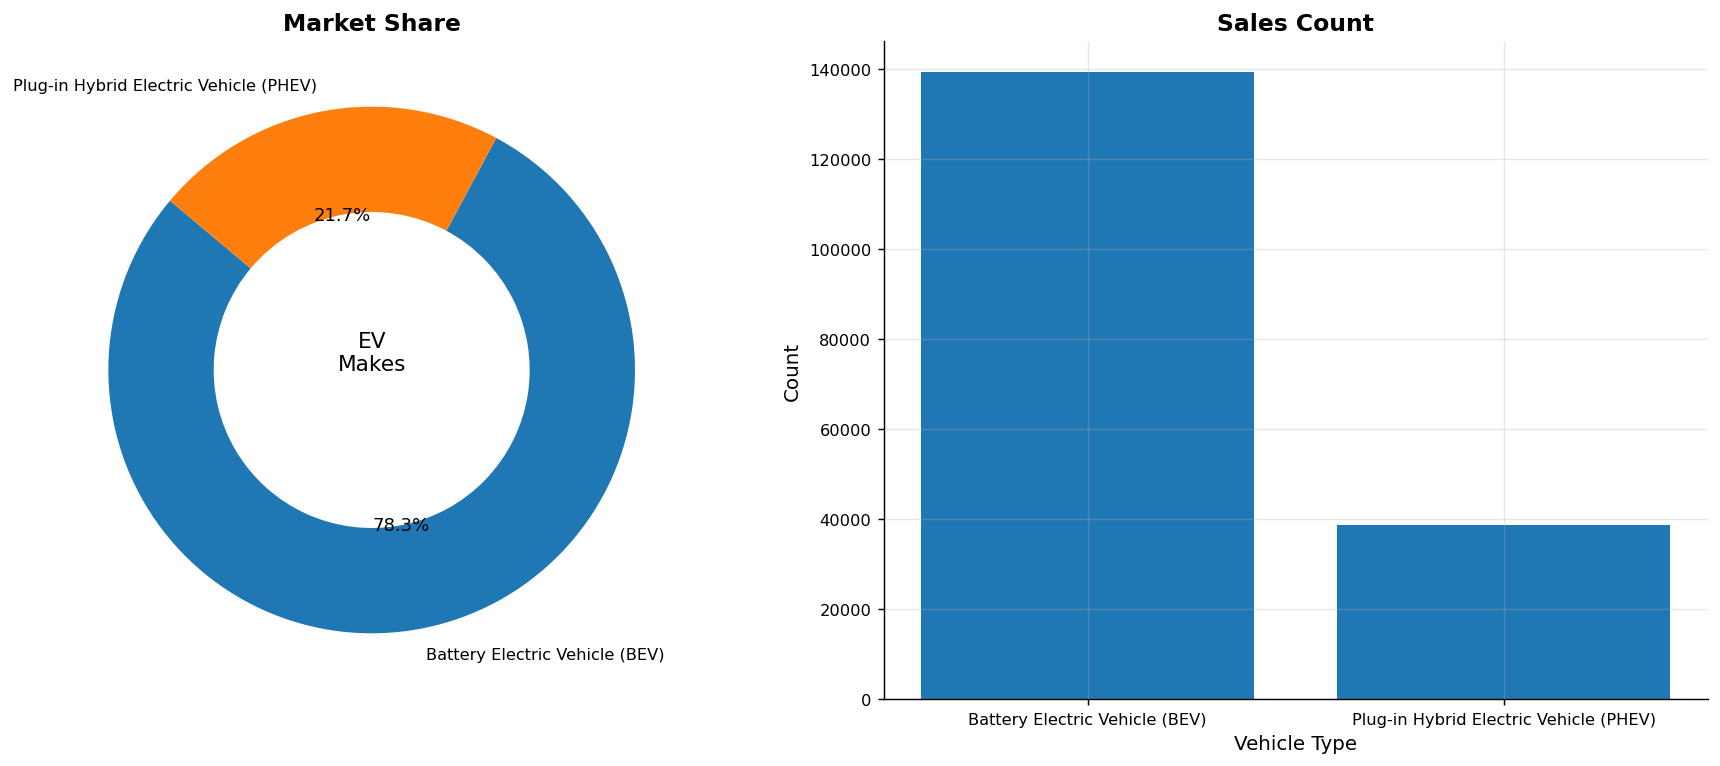

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(ev_counts, 
        labels =ev_counts.index,
        autopct='%1.1f%%',startangle=140,
        wedgeprops=dict(width=0.4)
        )
axes[0].text(0,0, "EV\nMakes", ha='center', fontsize=12)
axes[0].set_title("Market Share")


axes[1].bar(ev_counts.index,ev_counts.values)
axes[1].set_title("Sales Count")
axes[1].set_xlabel("Vehicle Type")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


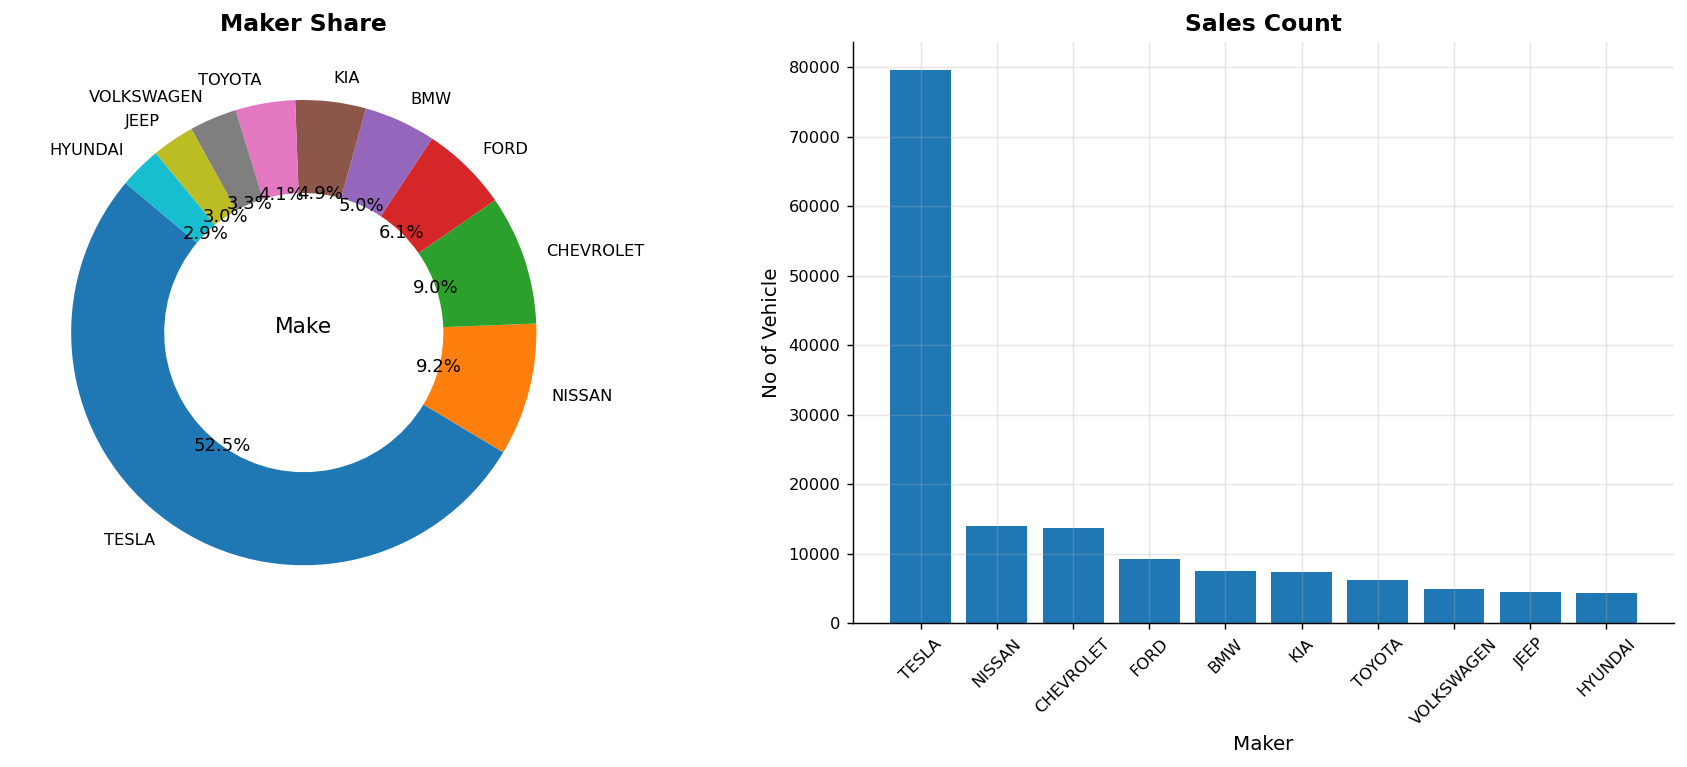

In [17]:
top_maker=df['Make'].value_counts().head(10)
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Donut Chart
axes[0].pie(
    top_maker.values,
    labels=top_maker.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.4)
)

axes[0].text(0, 0, "Make", ha='center', fontsize=12)
axes[0].set_title("Maker Share")


# Bar Chart
axes[1].bar(top_maker.index, top_maker.values)

axes[1].set_title("Sales Count")
axes[1].set_xlabel("Maker")
axes[1].set_ylabel("No of Vehicle")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


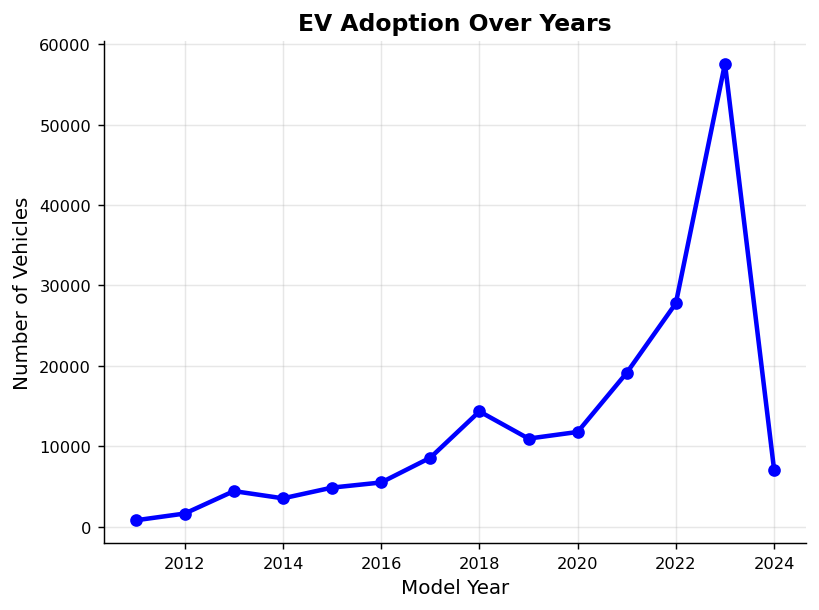

In [23]:
Adoption=df[df['Model Year']>2010]['Model Year'].value_counts().sort_index()
Adoption.plot(
    kind='line',
    color='blue',
    linewidth=2.5,
    marker='o',
    markersize=6
)

plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")
plt.title("EV Adoption Over Years")

plt.tight_layout()
plt.show()

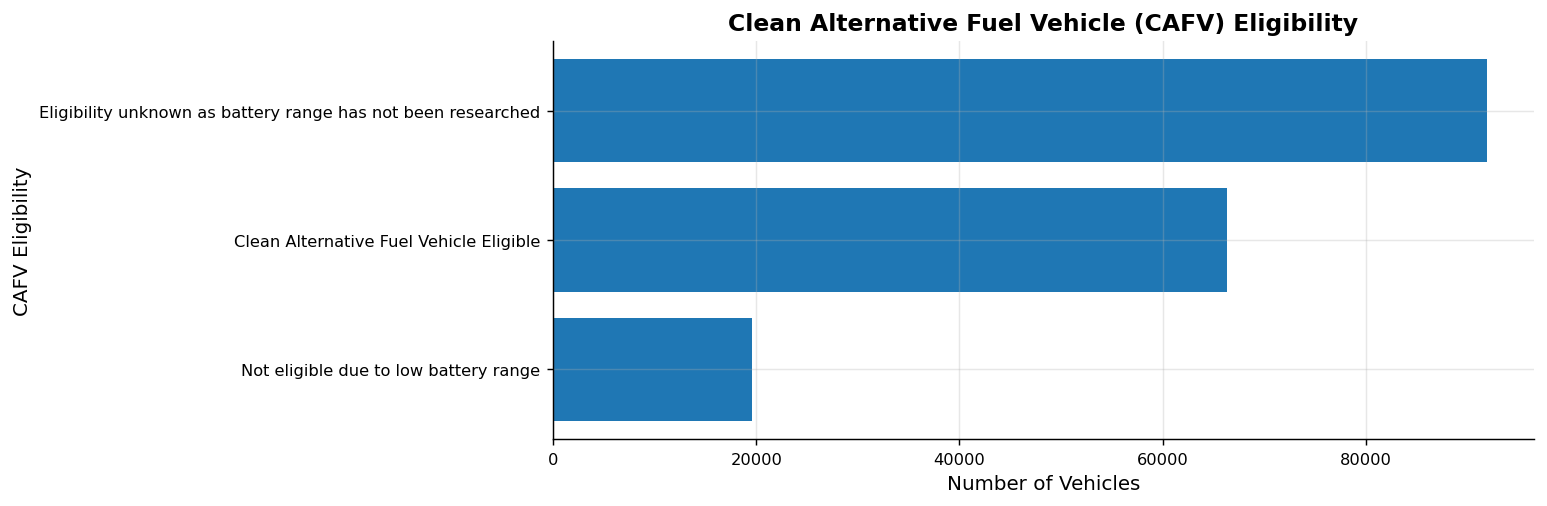

In [34]:
caf = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] \
        .value_counts() \
        .sort_values()

plt.figure(figsize=(12,4))

plt.barh(
    caf.index,
    caf.values
)

plt.title("Clean Alternative Fuel Vehicle (CAFV) Eligibility")
plt.xlabel("Number of Vehicles")
plt.ylabel("CAFV Eligibility")

plt.tight_layout()
plt.show()

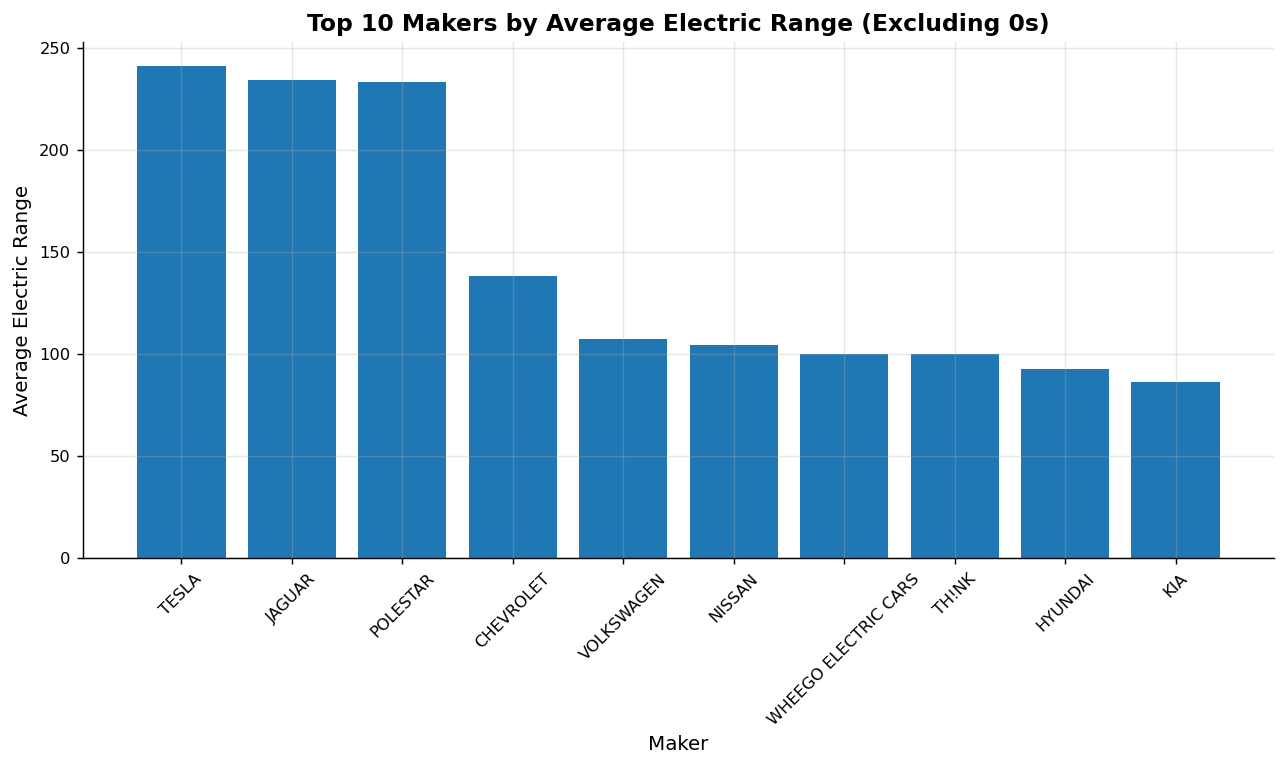

In [35]:
# Exclude 0 values first
df_filtered = df[df['Electric Range'] > 0]

# Average Electric Range by Make
range_by_make = (
    df_filtered.groupby('Make')['Electric Range']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.bar(
    range_by_make.index,
    range_by_make.values
)

plt.title("Top 10 Makers by Average Electric Range (Excluding 0s)")
plt.xlabel("Maker")
plt.ylabel("Average Electric Range")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

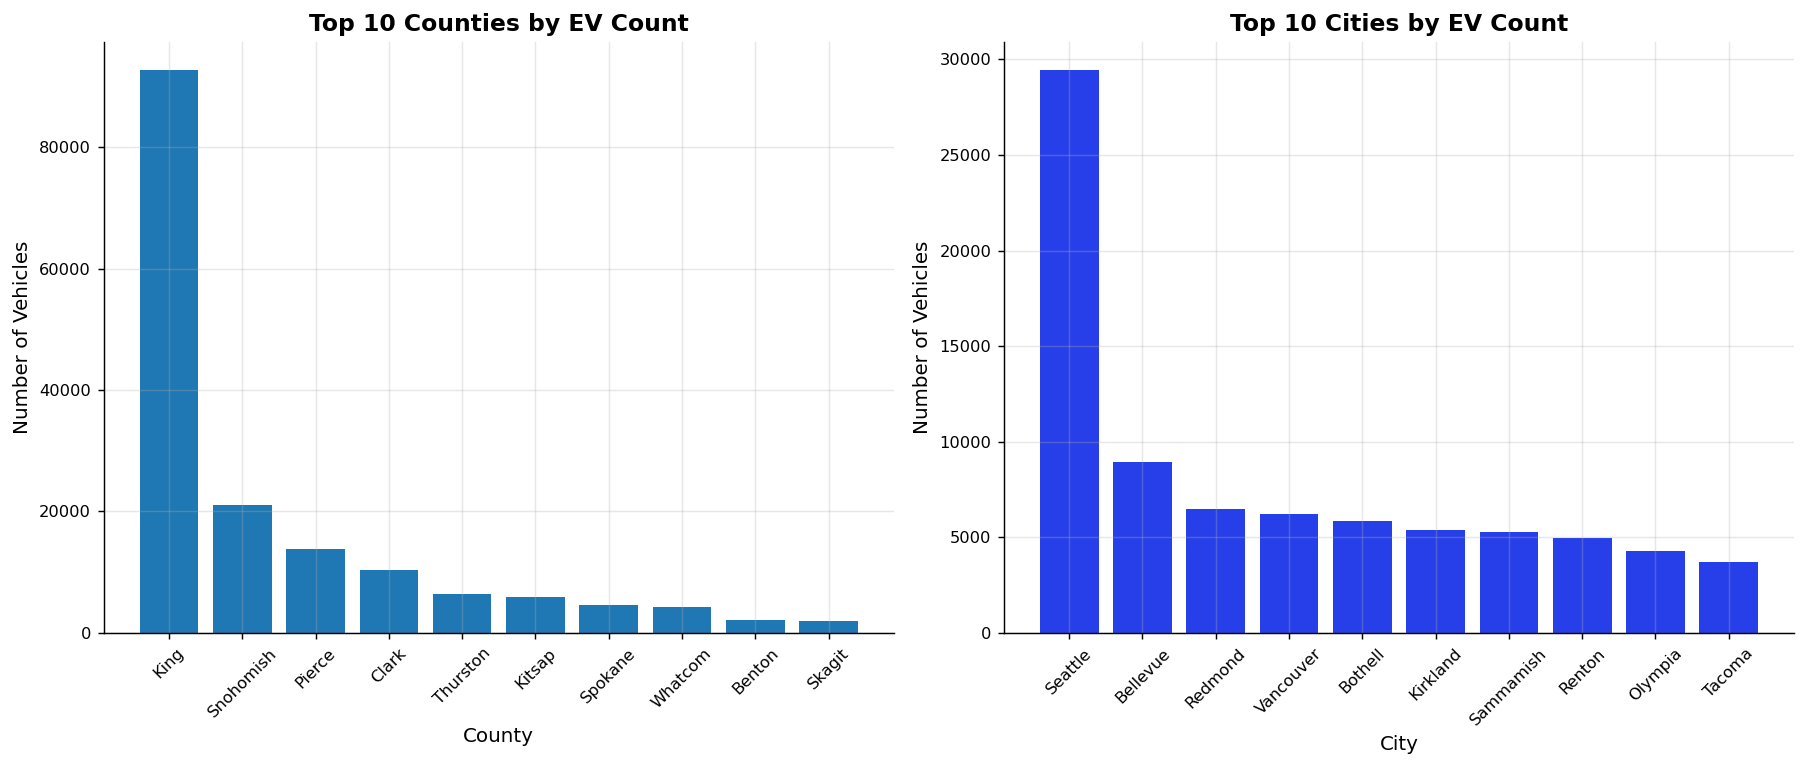

In [ ]:
top_counties = df['County'].value_counts().head(10)
top_cities = df['City'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ------------------ Counties ------------------
axes[0].bar(
    top_counties.index,
    top_counties.values
)

axes[0].set_title("Top 10 Counties by EV Count")
axes[0].set_xlabel("County")
axes[0].set_ylabel("Number of Vehicles")
axes[0].tick_params(axis='x', rotation=45)

# ------------------ Cities ------------------
axes[1].bar(
    top_cities.index,
    top_cities.values,
    alpha=0.7
)
axes[1].bar(top_cities.index, top_cities.values, color='purple', alpha=0.6)

axes[1].set_title("Top 10 Cities by EV Count")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Number of Vehicles")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [29]:
range_by_make = (
    df[df['Electric Range'] > 0]
    .groupby('Make')['Electric Range']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

In [58]:
bev_by_city = df[df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']['City'].value_counts().head(10)
phev_by_city = df[df['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)']['City'].value_counts().head(10)

comparison_city_df = pd.DataFrame({
    'BEV': bev_by_city,
    'PHEV': phev_by_city
}).fillna(0)

bev_by_county = df[df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']['County'].value_counts().head(10)
phev_by_county = df[df['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)']['County'].value_counts().head(10)

comparison_county_df = pd.DataFrame({
    'BEV': bev_by_county,
    'PHEV': phev_by_county
}).fillna(0)

comparison_city_df = comparison_city_df.head(10)
comparison_county_df = comparison_county_df.head(10)

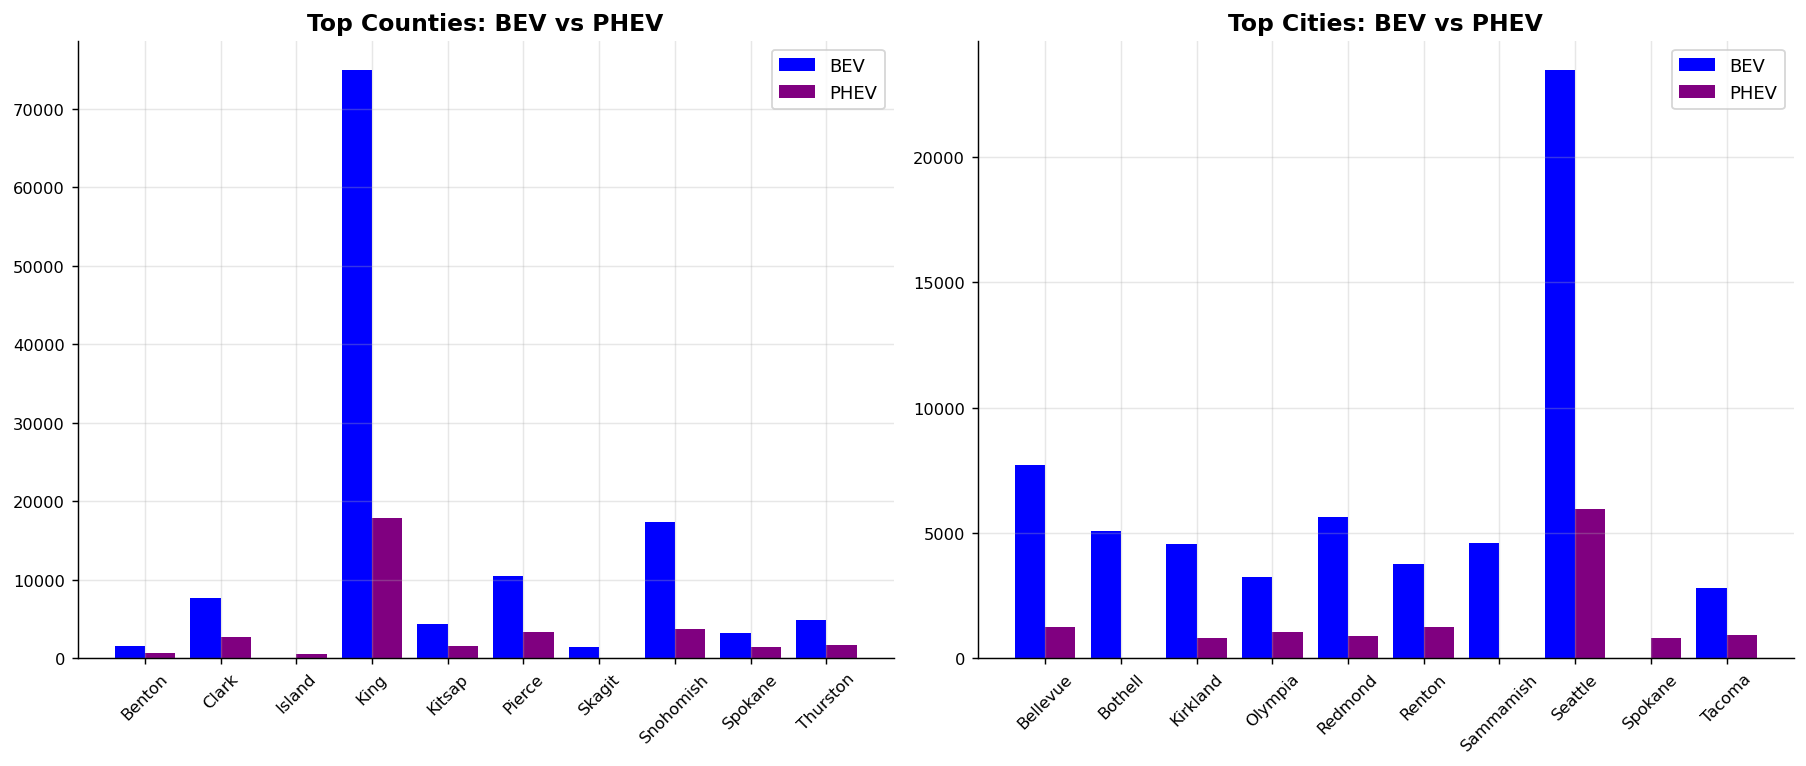

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ---------------- COUNTIES ----------------
y = np.arange(len(comparison_county_df.index))
width = 0.4

axes[0].bar(y - width/2, comparison_county_df['BEV'], width, label='BEV', color='blue')
axes[0].bar(y + width/2, comparison_county_df['PHEV'], width, label='PHEV', color='purple')

axes[0].set_xticks(y)
axes[0].set_xticklabels(comparison_county_df.index, rotation=45)
axes[0].set_title("Top Counties: BEV vs PHEV")
axes[0].legend()

# ---------------- CITIES ----------------
x = np.arange(len(comparison_city_df.index))

axes[1].bar(x - width/2, comparison_city_df['BEV'], width, label='BEV', color='blue')
axes[1].bar(x + width/2, comparison_city_df['PHEV'], width, label='PHEV', color='purple')

axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_city_df.index, rotation=45)
axes[1].set_title("Top Cities: BEV vs PHEV")
axes[1].legend()

plt.tight_layout()
plt.show()

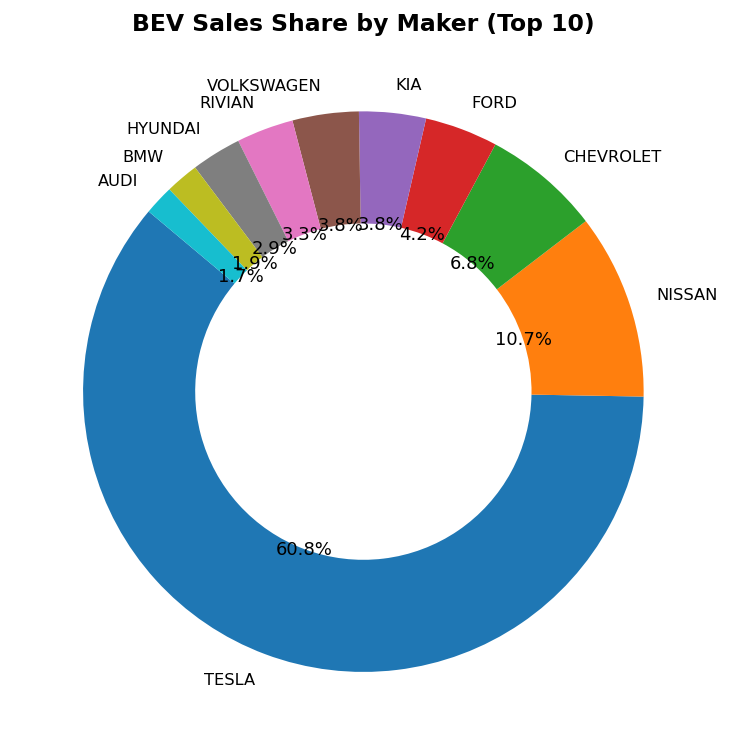

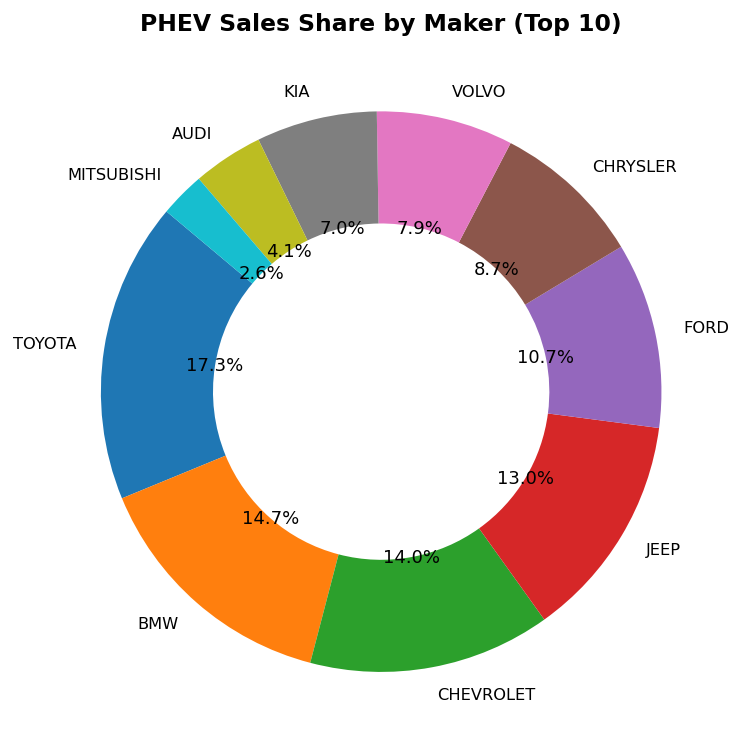

In [ ]:

#===================== Maker BEVs Share In the Market ===================================
bev_df = df[df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']
bev_make = bev_df['Make'].value_counts().head(10)

plt.figure(figsize=(7,7))

plt.pie(
    bev_make.values,
    labels=bev_make.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'width': 0.4}   # 👈 this makes it a donut
)

plt.title("BEV Sales Share by Maker (Top 10)")
plt.show()

#===================== Maker PHEVs Share In the Market ===================================

phev_df = df[df['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)']
phev_make = phev_df['Make'].value_counts().head(10)

plt.figure(figsize=(7,7))

plt.pie(
    phev_make.values,
    labels=phev_make.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'width': 0.4}
)

plt.title("PHEV Sales Share by Maker (Top 10)")
plt.show()